# Fast Capacitor Cycling: Primitives, Dead Time, and the Fast Cycling Job

Cycling a capacitor - charging and discharging it back and forth between two limits - is a compact way to see how the `zahner_link` measurement primitives fit together, and when it is worth reaching for a dedicated cycling job instead.

In this notebook we run the **same** experiment twice:

1. **Chained primitives** - the cycling is built from individual [`PogaJob`](https://doc.zahner.de/im7/apis/zahner_link/python/pages/meas.html#zahner_link.meas.PogaJob)s, one per charge/discharge step, each reversing at a voltage turn boundary via a stop condition.
2. **The [`FastCyclingJob`](https://doc.zahner.de/im7/apis/zahner_link/python/pages/meas.html#zahner_link.meas.FastCyclingJob)** - a single job that performs the complete cycling internally, switching between two values instead of chaining separate jobs.

Along the way we look at the small *dead time* between chained primitives: why it is a non-issue for the slow processes that primitives are made for, and how the fast cycling job removes it entirely for fast processes.

A 2200 µF capacitor is connected to the main potentiostat, and that basic steps such as connecting to and calibrating the device are already familiar from the other examples.

## Primitives, dead time, and fast cycling

The `zahner_link` measurement primitives - [`PogaJob`](https://doc.zahner.de/im7/apis/zahner_link/python/pages/meas.html#zahner_link.meas.PogaJob) (polarization), [`RampJob`](https://doc.zahner.de/im7/apis/zahner_link/python/pages/meas.html#zahner_link.meas.RampJob), [`OcvJob`](https://doc.zahner.de/im7/apis/zahner_link/python/pages/meas.html#zahner_link.meas.OcvJob), and so on - are the building blocks of an experiment. You run them one after another, and each one does exactly one well-defined thing. That simplicity is their strength: primitives combine freely, you can switch between potentiostatic and galvanostatic operation between them, change ranges, and [`append`](https://doc.zahner.de/im7/apis/zahner_link/python/pages/fundamental.html#zahner_link.DcDataset) the results into a single dataset.

Between two chained jobs there is a short handover: one job finishes, its result is collected, and the next job is prepared and started. This handover takes on the order of milliseconds and is called the **dead time**. During it the potentiostat simply keeps holding its last output, so the cell always stays under control.

For the processes primitives are designed for, this handover is a complete non-issue. A polarization step, a slow charge, an OCV relaxation - these run for seconds, minutes or hours, and a few milliseconds in between vanish far below the measurement resolution. The [`PogaJob`](https://doc.zahner.de/im7/apis/zahner_link/python/pages/meas.html#zahner_link.meas.PogaJob) even has a minimum runtime by design, which keeps you comfortably in the regime where the dead time cannot matter.

The picture only changes once the individual steps themselves become as short as that handover - for example charging and discharging a small capacitor within milliseconds. Chaining many very short primitives would put a handover after every step, with one subtle consequence: when a step reaches its turn boundary and ends, the potentiostat keeps applying that step's current during the handover, so the capacitor keeps charging for a brief moment before the next step reverses it. The reversal is delayed by the dead time and the voltage nudges a little past the turn boundary. This fast regime is exactly what the [`FastCyclingJob`](https://doc.zahner.de/im7/apis/zahner_link/python/pages/meas.html#zahner_link.meas.FastCyclingJob) is built for: instead of chaining separate jobs, it runs the whole charge/discharge cycling **inside a single job**, switching back and forth between two values (`first_step` and `second_step`). Because every step lives in the same job, there is no handover between steps and therefore no dead time - the reversal happens immediately at the turn boundary and the voltage stays within the limits. Both effects are visible in the Approach 1 and Approach 2 plots below: the chained primitives let the voltage overshoot ±1 V slightly, while the fast cycling job turns around right at ±1 V.

So the two approaches are not rivals; they cover different time scales. Primitives are the natural, readable choice for slow cycling, and the fast cycling job takes over seamlessly once the steps get short. This is the same idea that underlies the *wave* concept in general - see the [Primitives vs. Wave section of the FAQ](https://doc.zahner.de/im7/faq/index.html#primitives-vs-wave) for the background.

## Setup and Initialization

We import the libraries, connect to the IM7, and create the jobs reused throughout the notebook. The cycling is **galvanostatic** - we apply a current and let the voltage develop - so we prepare a galvanostatic switch-on job.

To make the two runs directly comparable, a small `reset_capacitor()` helper holds the cell potentiostatically at 0 V for two seconds before each run, so it always starts fully discharged from the same initial state. A second helper plots voltage and current against time and marks the turn boundaries.

In [ ]:
import copy
import sys
import time

import matplotlib.pyplot as plt
from matplotlib.ticker import EngFormatter
import zahner_link as zl

link = zl.ZahnerLinkExc("10.10.253.150", "1994")

try:
    link.connect()
    print("connected successfully")
except zl.ZahnerLinkException as e:
    error_object: zl.ErrorObject = e.error
    print(f"failed to connect, status: {error_object.get_error_code_enum()}, message: {error_object.get_message_formatted()}")
    sys.exit()

main_pot = "MAIN:1:POT"

# Galvanostatic operation: we drive a current and watch the voltage. Charging
# uses a positive current, discharging a negative one.
switch_on_gal_job = zl.control.SwitchOnJob(
    potentiostat=main_pot,
    coupling=zl.PotentiostatCoupling.GALVANOSTATIC,
    bias=0,  # start at 0 A
    voltage_range_index=0,
    compliance_range_index=0,
)
switch_off_job = zl.control.SwitchOffJob(potentiostat=main_pot)

# Reset job: hold the capacitor potentiostatically at 0 V so that every run
# starts from the same, fully discharged initial state.
reset_job = zl.control.SwitchOnJob(
    potentiostat=main_pot,
    coupling=zl.PotentiostatCoupling.POTENTIOSTATIC,
    bias=0.0,  # 0 V
    voltage_range_index=0,
    compliance_range_index=0,
)


def reset_capacitor(hold_time=2.0):
    """Bring the capacitor to a defined starting point: hold 0 V for hold_time seconds."""
    link.do_job(reset_job)
    time.sleep(hold_time)  # let the cell settle at 0 V
    link.do_job(switch_off_job)


def plot_cycling(dataset, title, turn_boundaries=None):
    t = dataset.get_dc_track("time")
    voltage = dataset.get_dc_track("voltage")
    current = dataset.get_dc_track("current")

    fig, ax1 = plt.subplots(figsize=(18, 10))
    ax2 = ax1.twinx()
    (line1,) = ax1.plot(t, voltage, color="blue", label="Voltage")
    (line2,) = ax2.plot(t, current, color="red", label="Current")

    if turn_boundaries is not None:
        for boundary in turn_boundaries:
            ax1.axhline(boundary, color="blue", linestyle=":", alpha=0.4)

    ax1.set_xlabel("Time")
    ax1.set_ylabel("Voltage")
    ax2.set_ylabel("Current")
    ax1.xaxis.set_major_formatter(EngFormatter(unit="s"))
    ax1.yaxis.set_major_formatter(EngFormatter(unit="V"))
    ax2.yaxis.set_major_formatter(EngFormatter(unit="A"))
    ax1.grid(which="both")
    ax1.legend(handles=[line1, line2], loc="upper right")
    plt.title(title)
    plt.tight_layout()
    plt.show()

connected successfully


## The experiment

We define the cycling once and reuse the exact same numbers for both approaches, so the comparison is fair. The cell is charged with `+1 mA` until it reaches `+1 V`, then discharged with `-1 mA` until it reaches `-1 V`, and so on. `num_cycles = 2.5` gives five half-steps, and after the last step the output is driven to a protective `end_value` of `0 A`.

At this speed autoranging is switched off and a fixed `current_range` is chosen to match the cell current - range switching cannot keep up with fast steps, which is the same reason the *wave* concept fixes the range.

In [19]:
first_step = 0.001            # +1 mA  -> charge
second_step = -0.001          # -1 mA  -> discharge
upper_turn_boundary = 1.0     # V, reverse here while charging
lower_turn_boundary = -1.0    # V, reverse here while discharging
end_value = 0.0               # A, protective value driven to after the last step
num_cycles = 2.5              # 2.5 full cycles -> 5 half-steps
step_time = 10.0              # s, maximum hold per step (safety limit)
output_data_rate = 10e3       # 10 kHz
current_range = max(abs(first_step), abs(second_step))

## Approach 1 - Cycling with chained primitives

First the explicit way, built from individual galvanostatic [`PogaJob`](https://doc.zahner.de/im7/apis/zahner_link/python/pages/meas.html#zahner_link.meas.PogaJob)s. Each step applies a constant current and runs until a voltage turn boundary is reached: while charging we watch the upper boundary with a [`MaxLimitStopCondition`](https://doc.zahner.de/im7/apis/zahner_link/python/pages/stopconditions.html#zahner_link.meas.stop.MaxLimitStopCondition), while discharging the lower boundary with a [`MinLimitStopCondition`](https://doc.zahner.de/im7/apis/zahner_link/python/pages/stopconditions.html#zahner_link.meas.stop.MinLimitStopCondition). When the boundary is hit the job stops, its data is collected, and the next step starts with the opposite current - this handover is where the small dead time sits.

We alternate `first_step` (charge) and `second_step` (discharge) and [`append`](https://doc.zahner.de/im7/apis/zahner_link/python/pages/fundamental.html#zahner_link.DcDataset) every step into one continuous [`DcDataset`](https://doc.zahner.de/im7/apis/zahner_link/python/pages/fundamental.html#zahner_link.DcDataset). After the cycles, a final 0 A polarization holds the protective end value, and the whole run is plotted as a single curve.

In [20]:
# Alternate the two step currents: first_step, second_step, first_step, ...
half_steps = round(num_cycles * 2)
step_currents = [first_step if i % 2 == 0 else second_step for i in range(half_steps)]

reset_capacitor()  # start from a defined, fully discharged state
link.do_job(switch_on_gal_job)

poga_dataset = None
for step_index, step_current in enumerate(step_currents):
    if step_current > 0:
        # charging: reverse when the upper voltage boundary is reached
        turn_stop_condition = zl.meas.stop.MaxLimitStopCondition(
            for_dimension="voltage", maximum=upper_turn_boundary
        )
    else:
        # discharging: reverse when the lower voltage boundary is reached
        turn_stop_condition = zl.meas.stop.MinLimitStopCondition(
            for_dimension="voltage", minimum=lower_turn_boundary
        )

    step = zl.meas.PogaJob(
        bias=step_current,
        duration=step_time,
        output_data_rate=output_data_rate,
        autorange=False,
        current_range=current_range,
        stop_conditions=[turn_stop_condition],
    )
    try:
        link.do_job(step)
    except zl.ZahnerLinkException as e:
        # Reaching a turn boundary is the expected way for a step to end.
        if e.error.get_error_code_enum() != zl.ErrorCodeEnum.STOP_CONDITION_TRIGGERED:
            raise

    step_data = link.get_job_result_data(step)
    if poga_dataset is None:
        poga_dataset = copy.deepcopy(step_data)
    else:
        # append() continues the time axis seamlessly; the millisecond dead time
        # between the chained jobs is not part of the recorded data.
        poga_dataset.append(step_data)

# Hold the protective end value with a final 0 A polarization, then switch off.
end_poga = zl.meas.PogaJob(
    bias=end_value,  # 0 A
    duration=2.0,
    output_data_rate=output_data_rate,
    autorange=False,
    current_range=current_range,
)
link.do_job(end_poga)
poga_dataset.append(link.get_job_result_data(end_poga))
link.do_job(switch_off_job)

print(f"chained {len(step_currents)} primitives into {poga_dataset.get_row_count()} data points")

chained 5 primitives into 461093 data points


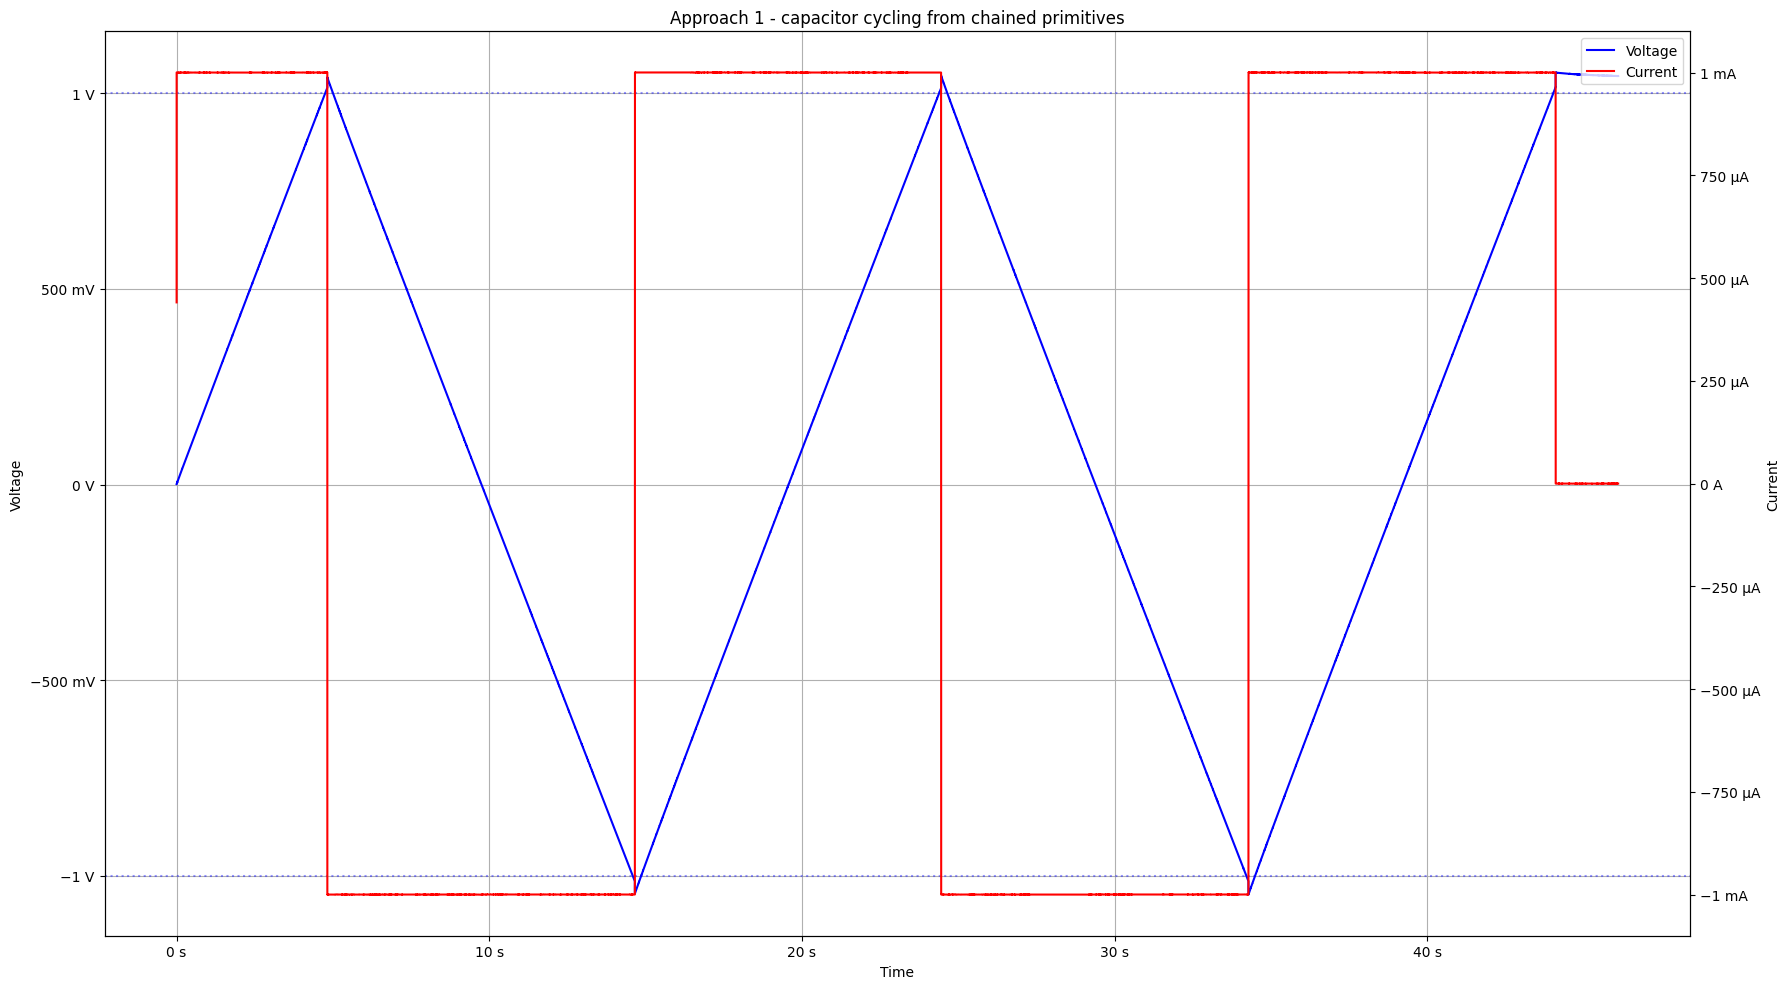

In [21]:
plot_cycling(
    poga_dataset,
    "Approach 1 - capacitor cycling from chained primitives",
    turn_boundaries=[lower_turn_boundary, upper_turn_boundary],
)

## Approach 2 - The Fast Cycling Job

The [`FastCyclingJob`](https://doc.zahner.de/im7/apis/zahner_link/python/pages/meas.html#zahner_link.meas.FastCyclingJob) expresses the very same experiment as a single job. It jumps to `first_step` and holds until the `upper_turn_boundary` is crossed (`turn_limit_check=True`) or `step_time` elapses, then jumps to `second_step`, and so on for `num_cycles`. After the last step it drives to `end_value`.

Because the whole cycling lives in one job, the reversals happen internally with no handover between steps - there is no dead time. The parameters map one-to-one to the shared definition above.

In [22]:
fast_cycling_job = zl.meas.FastCyclingJob(
    first_step=first_step,
    second_step=second_step,
    end_value=end_value,
    step_time=step_time,
    output_data_rate=output_data_rate,
    num_cycles=num_cycles,
    autorange=False,
    current_range=current_range,
    turn_limit_check=True,
    upper_turn_boundary=upper_turn_boundary,
    lower_turn_boundary=lower_turn_boundary,
)

reset_capacitor()  # same defined starting point as approach 1
link.do_job(switch_on_gal_job)
link.do_job(fast_cycling_job)

# Hold the protective end value with a final 0 A polarization, matching approach 1.
end_poga = zl.meas.PogaJob(
    bias=end_value,  # 0 A
    duration=2.0,
    output_data_rate=output_data_rate,
    autorange=False,
    current_range=current_range,
)
link.do_job(end_poga)
link.do_job(switch_off_job)

fast_cycling_dataset = link.get_job_result_data(fast_cycling_job)
fast_cycling_dataset.append(link.get_job_result_data(end_poga))
print(f"single fast cycling job -> {fast_cycling_dataset.get_row_count()} data points")

single fast cycling job -> 449172 data points


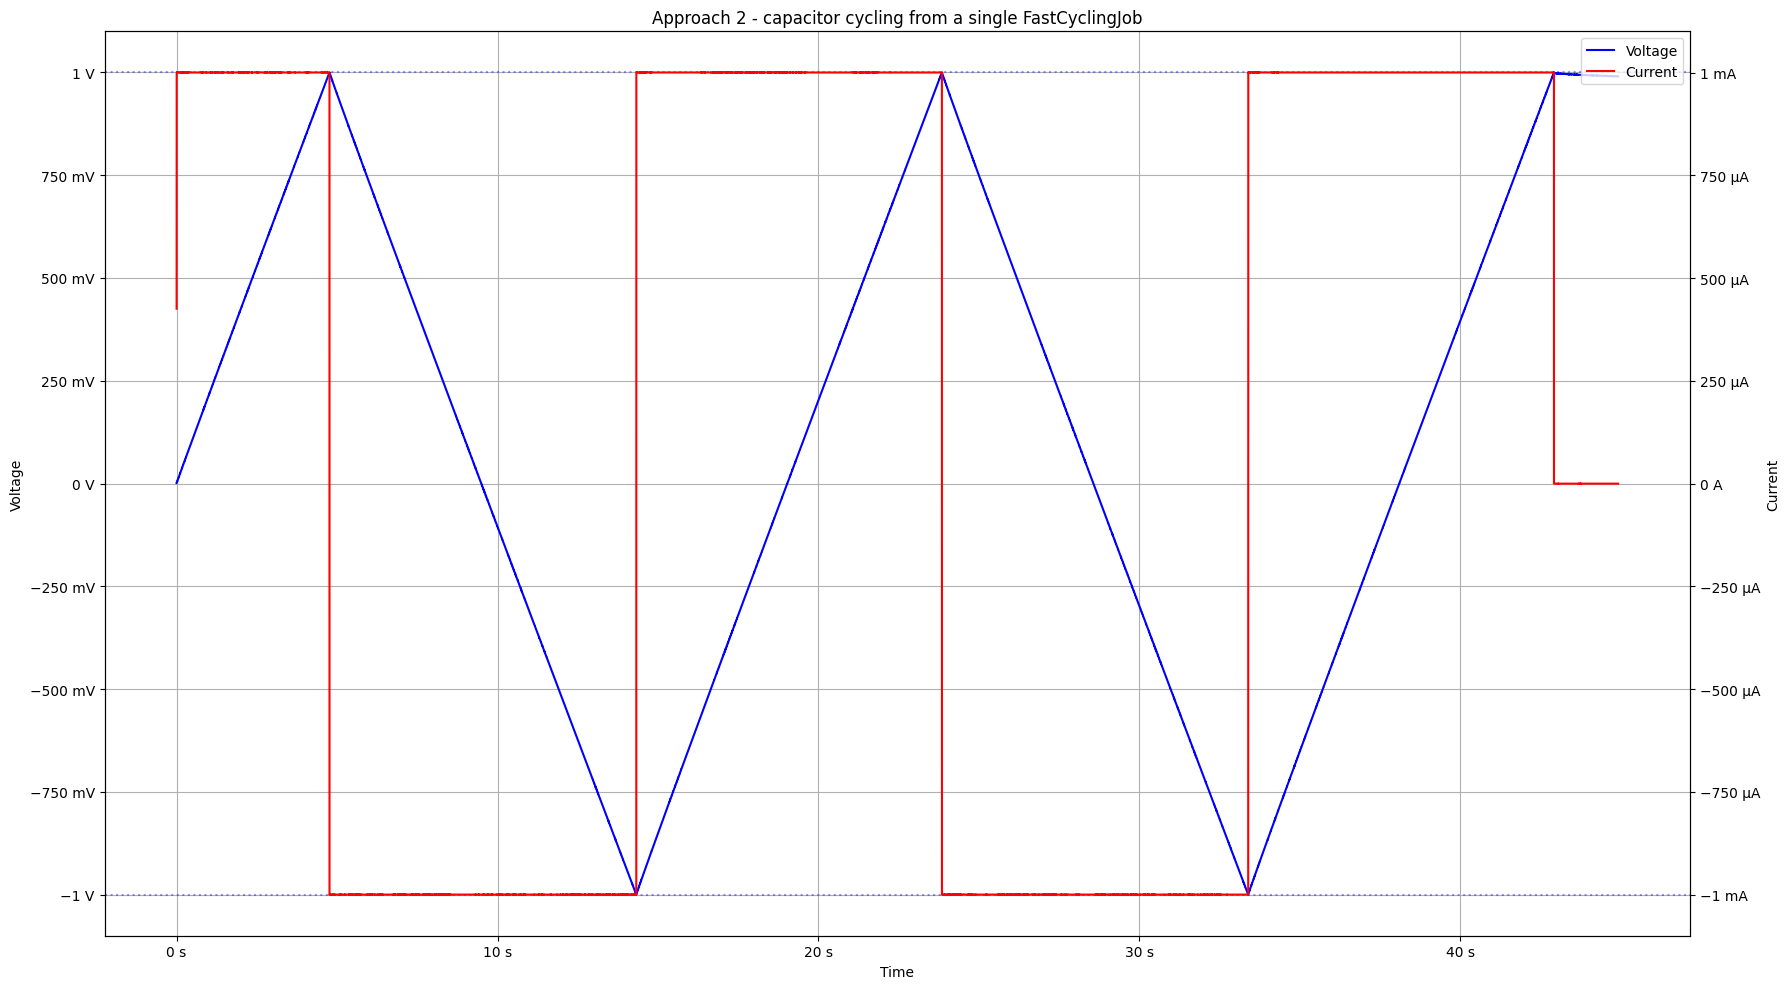

In [23]:
plot_cycling(
    fast_cycling_dataset,
    "Approach 2 - capacitor cycling from a single FastCyclingJob",
    turn_boundaries=[lower_turn_boundary, upper_turn_boundary],
)

## Choosing between the two

Both approaches produce the same charge/discharge cycling; they simply live at different time scales.

| Aspect | Chained primitives (`PogaJob`) | `FastCyclingJob` |
| --- | --- | --- |
| Ideal time scale | seconds per step and slower | milliseconds per step |
| Dead time between steps | present, but negligible at slow speeds | none - every step is in one job |
| Turn boundary | slightly overshot - voltage nudges past ±1 V | held exactly - voltage stays within ±1 V |
| Flexibility | very high: mix jobs, change mode and range | focused on one fast cycling task |
| Autoranging | available | fixed range for maximum speed |
| Reads like | an explicit, step-by-step recipe | one compact job |

Comparing the two plots, this shows up right at the turning points: with the chained primitives the voltage nudges slightly past ±1 V, because the step current keeps flowing during each handover and charges the cell a little further, whereas the fast cycling job turns around exactly at ±1 V and never exceeds it.

**Bottom line:** reach for primitives whenever the process is slow enough that the millisecond handover disappears into the measurement - which is most of the time - and switch to the fast cycling job when the steps themselves get that short.

## Disconnecting

The potentiostat was already switched off after each run, so we only need to disconnect from the device. The job objects and datasets remain available afterwards.

In [24]:
link.disconnect()